In [107]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
import scipy.optimize as so
import astropy.constants as c
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
from matplotlib.collections import LineCollection, PolyCollection
from matplotlib import cm, colors
import matplotlib.animation as animation
plt.rcParams['figure.dpi'] = 100
print(sys.path)
from pprint import pprint 

['/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/SpecFANN', '/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/anaconda3/envs/spamms/lib/python310.zip', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/lib-dynload', '', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/site-packages', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS']


In [89]:
input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)

run_dictionaries = sp.create_runs_and_ids(fit_param_values)

Reading input file...


In [90]:
pprint(run_dictionaries) #paramter permutations

[{'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 20.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 0,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.0,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 650.0,
  'zeta_T': 650.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 20.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 1,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.25,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 650.0,
  'zeta_T': 650.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 20.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 2,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.5,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 650.0,
  'zeta_T': 650.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 20.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 3,
  't0': 0.0,
  'teff': 35000.0,
  'v

In [91]:
run_dictionary = run_dictionaries[4] # CHANGE THIS TO SELECT WHICH MODEL TO PLOT If using the unchanged input file, 0 is no rotation, 1 is 0.25 crit, and 2 is 0.9 crit
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)

100%|██████████| 2/2 [00:00<00:00,  2.00it/s]


In [108]:
s

<PHOEBE Bundle: 483 parameters | contexts: model, setting, dataset, compute, figure, component, system, constraint>

In [92]:
phcb = s['%09.6f'%s['times@dataset@lc'].value]

verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
teffs = phcb['mesh@primary@mesh01@teffs'].get_value()
mus = phcb['mesh@primary@mesh01@mus'].get_value()
rvs = phcb['rvs@primary@mesh'].get_value()

xs = verts[:, :, 0]
ys = verts[:, :, 1]
zs = verts[:, :, 2]
print(xs.shape, ys.shape, zs.shape)  # [polygon, vertex]

(11406, 3) (11406, 3) (11406, 3)


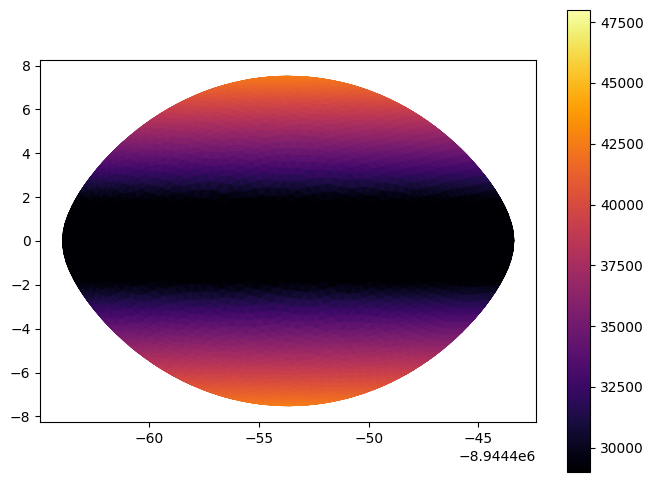

In [93]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = teffs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.inferno(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.inferno(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='inferno'), ax=axs)
plt.show()

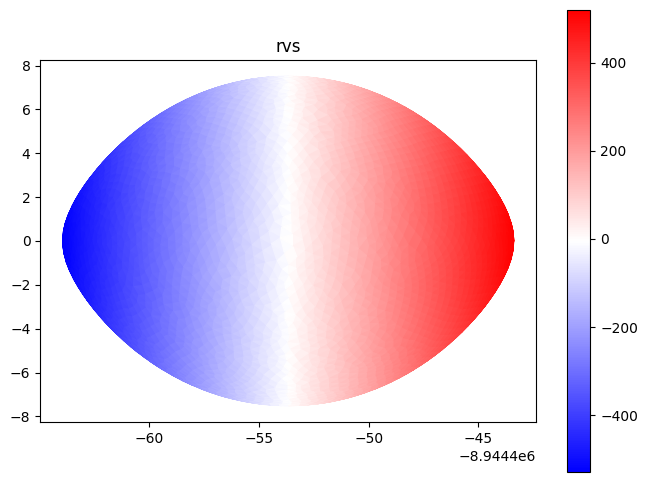

In [94]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = rvs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('rvs')
plt.show()

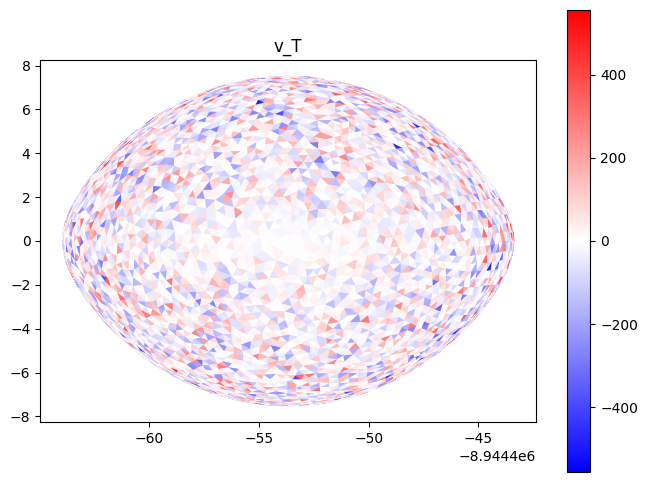

In [101]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_T = np.random.normal(0, 350, size=inds.shape[0])
theta_T = np.random.uniform(0, 2*np.pi, size=inds.shape[0])
theta_mu = np.arccos(mus)
v_T = 0.5 * zeta_T * np.sin(theta_mu) * np.cos(theta_T)


fc = v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_T')
plt.show()

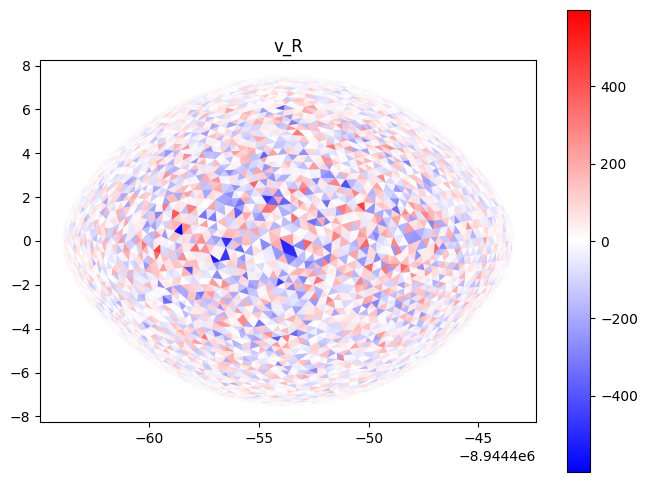

In [102]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_R = np.random.normal(0, 350, size=inds.shape[0])
v_R = 0.5 * zeta_R * mus


fc = v_R
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R')
plt.show()

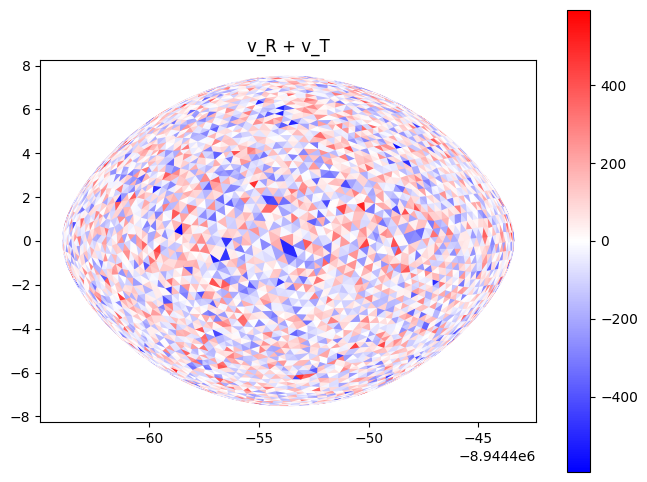

In [103]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R + v_T')
plt.show()

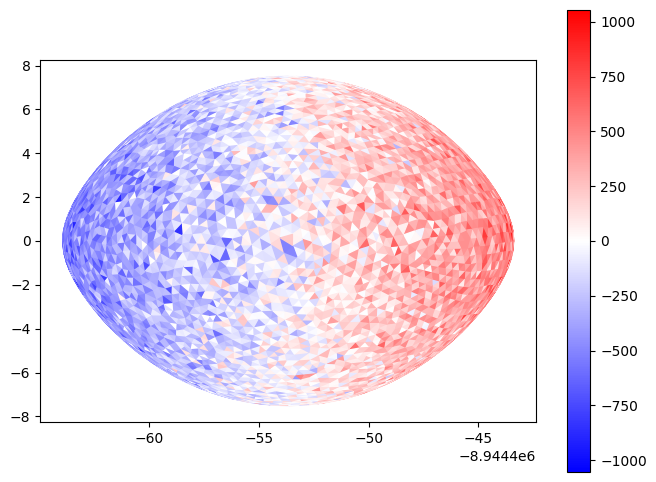

In [104]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T + rvs
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.show()

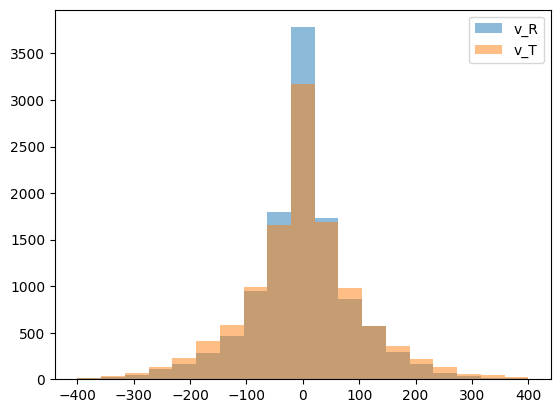

In [105]:
bins = np.linspace(-400, 400, 20)
plt.hist(v_R, alpha=0.5, bins=bins, label='v_R')
plt.hist(v_T, alpha=0.5, bins=bins, label='v_T')
plt.legend(loc='upper right')
plt.show()

In [106]:
print(np.std(v_R), np.std(v_T))

91.92323548017383 106.3420914294677


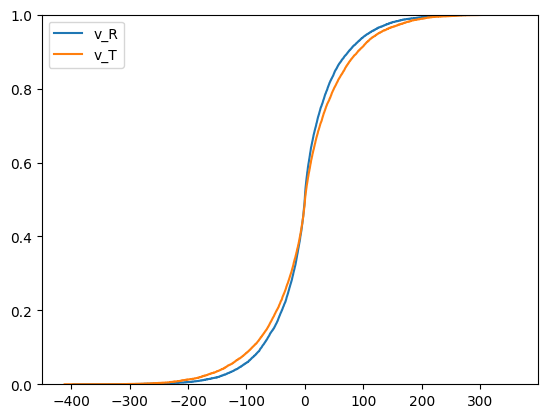

In [34]:
plt.ecdf(v_R, label='v_R')
plt.ecdf(v_T, label='v_T')
plt.legend(loc='upper left')
plt.show()